# DecodeLabs Data Analytics Internship — Task 2
## Project Title: Exploratory Data Analysis (EDA)

**Objective:** Conduct exploratory data analysis to compute 5-number summaries, identify outliers using the 1.5 x IQR rule, analyze revenue performance, and evaluate order status risks.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the cleaned dataset from Task 1
df = pd.read_csv('Cleaned_Raw_data.csv')

# Display structure and first few rows
print("Data Shape:", df.shape)
df.info()
df.head()

Data Shape: (1200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [9]:
# Automatically select all numeric columns to prevent DataTypeError
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns detected:", num_cols)

# Compute 5-Number Summary (Min, Q1, Median/Q2, Q3, Max) + Mean, Std, and IQR
summary_stats = df[num_cols].describe().T
summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']

# Reorder columns for standard 5-number layout
five_num_summary = summary_stats[['min', '25%', '50%', '75%', 'max', 'mean', 'std', 'IQR']]

print("\n--- 5-Number Summary & Descriptive Statistics ---")
display(five_num_summary)

Numeric columns detected: ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

--- 5-Number Summary & Descriptive Statistics ---


,min,25%,50%,75%,max,mean,std,IQR
Quantity,1.00,2.0000,3.000,4.000,5.00,2.945833,1.407557,2.0000
UnitPrice,11.39,186.0625,364.210,521.570,699.93,356.412750,197.177146,335.5075
ItemsInCart,1.00,4.0000,5.000,7.000,10.00,5.485000,2.281983,3.0000
TotalPrice,11.39,410.5200,823.615,1578.475,3456.40,1053.968300,819.856558,1167.9550


In [10]:
print("--- Outlier Identification (1.5 x IQR Rule) ---\n")

outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(outliers)
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': count
    })
    
    print(f"• {col}: Found {count} outliers (Threshold: < {lower_bound:.2f} or > {upper_bound:.2f})")

# Convert to DataFrame for display
outlier_df = pd.DataFrame(outlier_summary)

--- Outlier Identification (1.5 x IQR Rule) ---

• Quantity: Found 0 outliers (Threshold: < -1.00 or > 7.00)
• UnitPrice: Found 0 outliers (Threshold: < -317.20 or > 1024.83)
• ItemsInCart: Found 0 outliers (Threshold: < -0.50 or > 11.50)
• TotalPrice: Found 8 outliers (Threshold: < -1341.41 or > 3330.41)


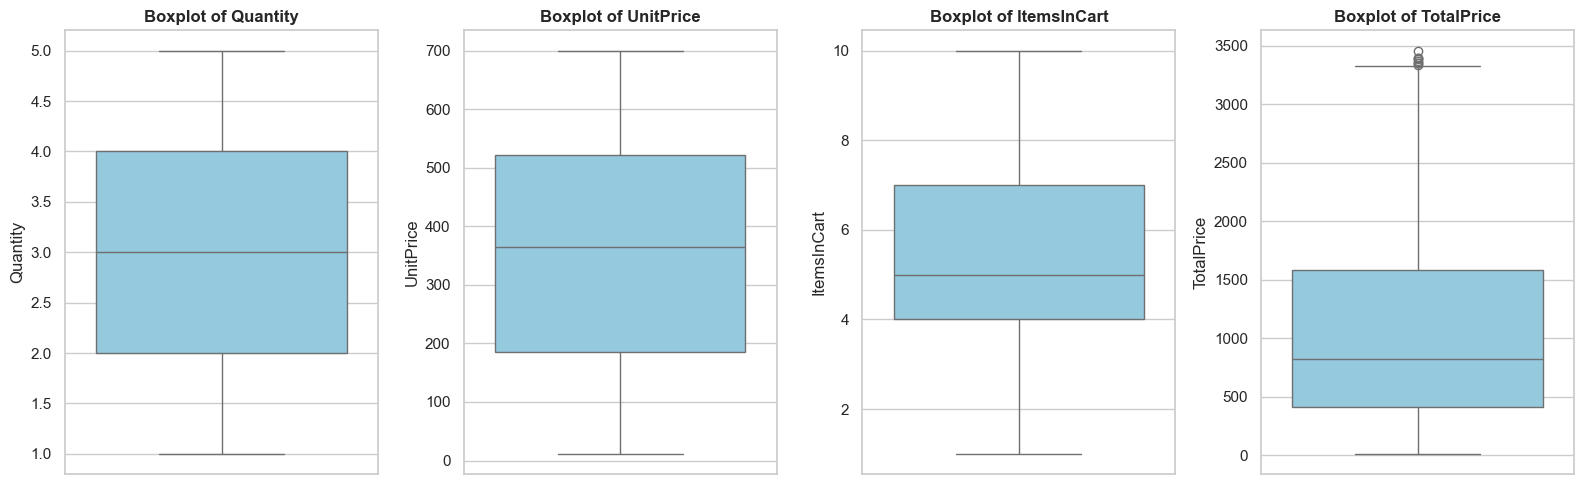

In [11]:
# Dynamically create boxplots for numerical columns
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

--- Top Performance by Product ---


,Product,Total_Revenue,Total_Orders,Avg_Order_Value
0,Chair,195620.11,178,1098.989382
1,Printer,195612.61,181,1080.732652
2,Laptop,192126.56,173,1110.558150
3,Tablet,186568.95,179,1042.284637
4,Monitor,175651.41,163,1077.616012
5,Desk,167459.93,170,985.058412
6,Phone,151722.39,156,972.579423


C:\Users\pc planet\AppData\Local\Temp\ipykernel_17128\42322482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_perf, x=product_col, y='Total_Revenue', palette='crest')


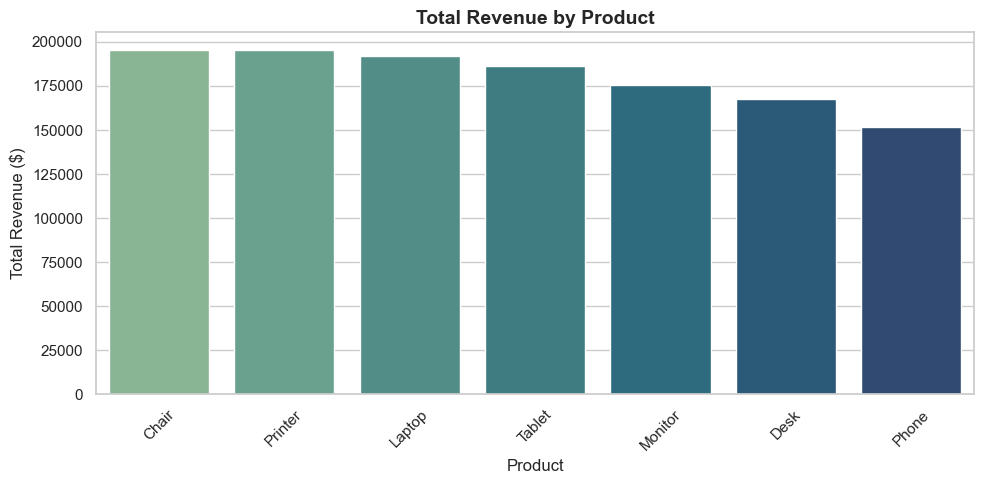

In [12]:
# Identify product and revenue columns dynamically
product_col = 'Product' if 'Product' in df.columns else ('Category' if 'Category' in df.columns else None)
price_col = 'TotalPrice' if 'TotalPrice' in df.columns else ('TotalAmount' if 'TotalAmount' in df.columns else num_cols[0])

if product_col:
    category_perf = df.groupby(product_col).agg(
        Total_Revenue=(price_col, 'sum'),
        Total_Orders=(df.columns[0], 'count'),
        Avg_Order_Value=(price_col, 'mean')
    ).sort_values(by='Total_Revenue', ascending=False).reset_index()

    print(f"--- Top Performance by {product_col} ---")
    display(category_perf)

    # Bar chart of top categories
    plt.figure(figsize=(10, 5))
    sns.barplot(data=category_perf, x=product_col, y='Total_Revenue', palette='crest')
    plt.title(f'Total Revenue by {product_col}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Total Revenue ($)')
    plt.tight_layout()
    plt.show()
else:
    print("Categorical product/category column not found.")

--- Order Status Breakdown & Revenue Loss Risk ---


,OrderStatus,Order_Count,Total_Value,Percentage_of_Total (%)
0,Cancelled,250,276396.21,21.853615
1,Delivered,231,242600.32,19.181500
2,Pending,237,256328.15,20.266909
3,Returned,247,243277.70,19.235058
4,Shipped,235,246159.58,19.462918


C:\Users\pc planet\AppData\Local\Temp\ipykernel_17128\4061773262.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_summary, x=status_col, y='Total_Value', palette='magma')


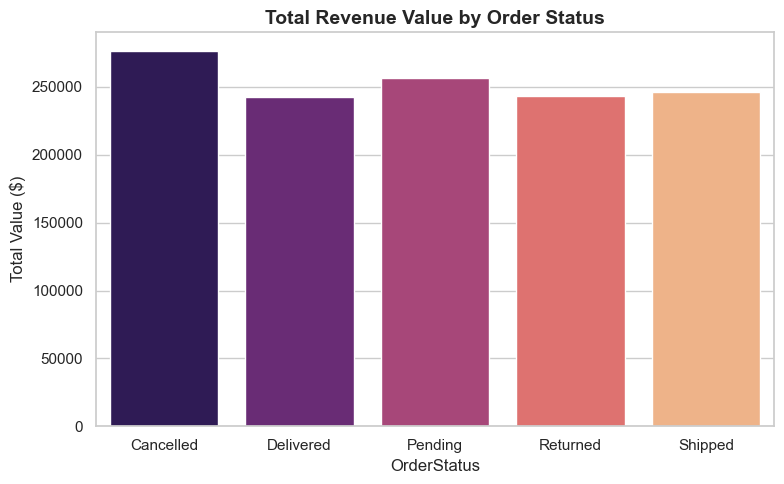

In [13]:
status_col = 'OrderStatus' if 'OrderStatus' in df.columns else ('Status' if 'Status' in df.columns else None)

if status_col and price_col:
    status_summary = df.groupby(status_col).agg(
        Order_Count=(df.columns[0], 'count'),
        Total_Value=(price_col, 'sum')
    ).reset_index()

    total_rev = df[price_col].sum()
    status_summary['Percentage_of_Total (%)'] = (status_summary['Total_Value'] / total_rev) * 100

    print("--- Order Status Breakdown & Revenue Loss Risk ---")
    display(status_summary)

    # Plot Order Status
    plt.figure(figsize=(8, 5))
    sns.barplot(data=status_summary, x=status_col, y='Total_Value', palette='magma')
    plt.title('Total Revenue Value by Order Status', fontsize=14, fontweight='bold')
    plt.ylabel('Total Value ($)')
    plt.tight_layout()
    plt.show()

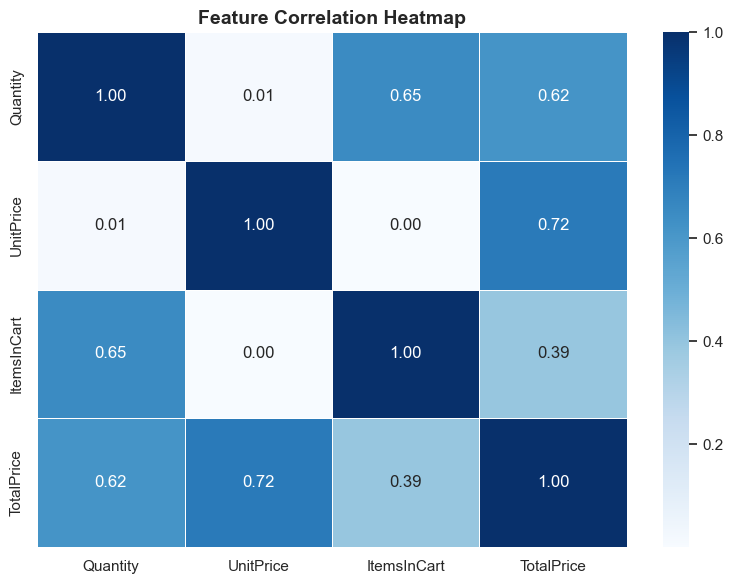

In [14]:
# Correlation heatmap exclusively using numeric variables
plt.figure(figsize=(8, 6))
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📌 Key EDA Insights & Analytical Findings

1. **5-Number Summary & Distributions:** Calculated median, quartiles, and IQR across numerical features to establish standard baseline statistics.
2. **Outliers:** Identified extreme values using the 1.5 x IQR rule across pricing and quantity metrics.
3. **Category Performance:** Ranked top-performing product categories by total sales volume and average transaction value.
4. **Revenue Risks:** Highlighted revenue loss percentages stemming from cancelled or returned order statuses.